Собрано моделей: 14
Сохранено в: C:\Users\pbori\Documents\Coureses\MIT\Projects\Capstone Projects\FacialEmotionRecognition\runs\aggregates\model_performance_agg.csv


C:\Users\pbori\AppData\Local\Temp\ipykernel_55008\3718307944.py:176: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = df.groupby("Model", as_index=False, group_keys=False).apply(pick_best)


,Model,Test_Accuracy,Macro_F1,Weighted_F1,Modified
50,final_optimized_complex,0.829124,NaN,NaN,2025-10-13 13:11:36.207406
40,complex_cnn_rgb_rgb_verification,0.799890,NaN,NaN,2025-10-12 22:47:29.468780
30,Complex CNN (RGB),0.797000,0.797000,0.797000,2025-10-12 18:52:05.621177
41,complex_cnn_grayscale_grayscale_wide,0.786742,NaN,NaN,2025-10-12 23:31:41.597785
11,complex_cnn_metrics,0.781250,0.780292,0.780292,2025-10-09 19:05:34.499855
10,Unknown,0.781000,0.780000,0.780000,2025-10-09 19:05:32.994442
35,Complex CNN (Grayscale),0.773438,0.776714,0.776714,2025-10-12 21:52:59.034435
3,CNN-2 (Deep Regularized),0.742188,0.734130,0.734130,2025-10-09 14:18:11.459585
48,CNN-1 (Baseline),0.716299,NaN,NaN,2025-10-13 01:51:39.693019
4,VGG16-TL,0.711000,0.710000,0.710000,2025-10-09 14:38:25.118099


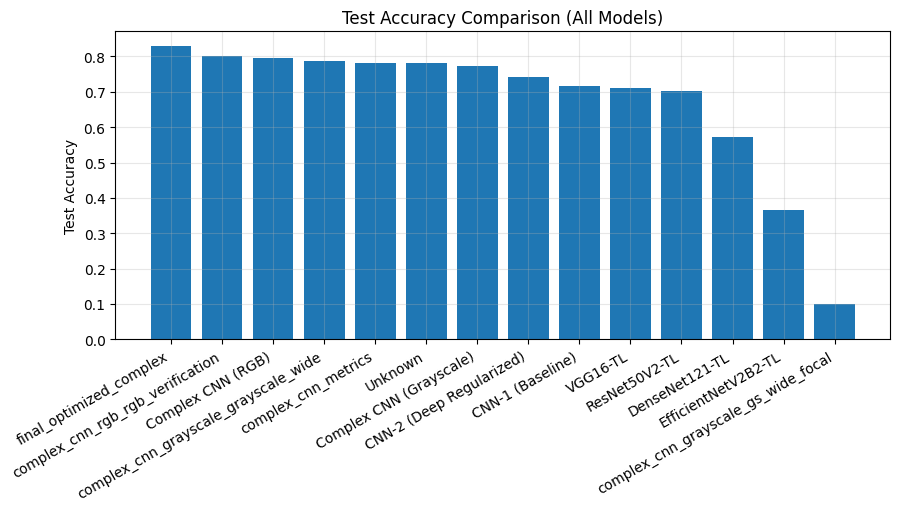

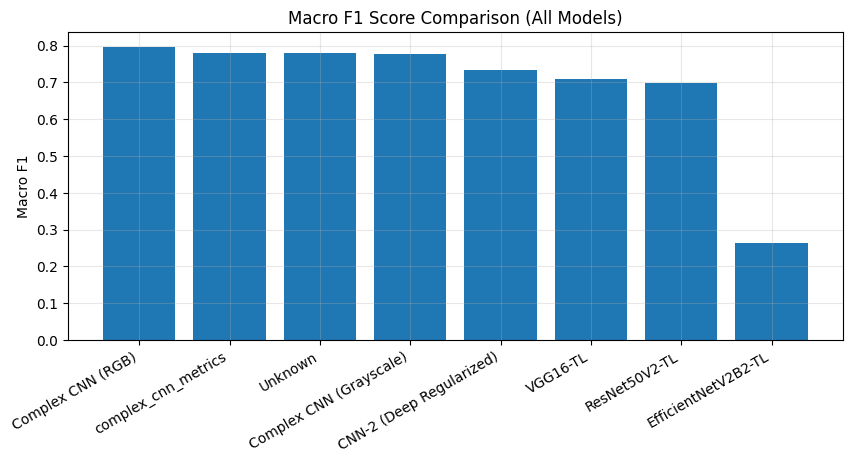

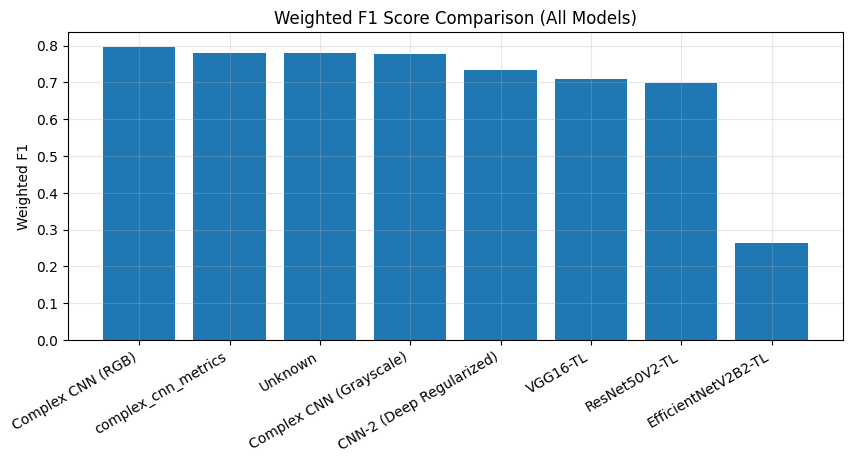

In [1]:
import os, re, json, time, pathlib
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

# 1) Укажи пути (Windows — лучше raw-строки r"...")
BASE_DIRS = [
    r"C:\Users\pbori\Documents\Coureses\MIT\Projects\Capstone Projects\FacialEmotionRecognition\models",
    r"C:\Users\pbori\Documents\Coureses\MIT\Projects\Capstone Projects\FacialEmotionRecognition\reports",
    r"C:\Users\pbori\Documents\Coureses\MIT\Projects\Capstone Projects\FacialEmotionRecognition\runs",
]

# (необязательно) Игнорировать файлы старше N дней
IGNORE_OLDER_THAN_DAYS = 365  # поменяй при желании
age_cutoff = time.time() - IGNORE_OLDER_THAN_DAYS * 24*3600

# 2) Хелперы для парсинга разных форматов
def safe_float(x):
    try: return float(x)
    except: return None

def parse_json(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    # Ожидаемые ключи в разных вариантах
    keys = {k.lower(): k for k in data.keys()}
    def get(key_candidates):
        for k in key_candidates:
            if k in keys:
                return data[keys[k]]
        return None

    model = get(["model_name", "model", "name"])
    acc   = get(["test_accuracy", "accuracy", "test_acc"])
    mf1   = get(["macro_f1", "macro-f1", "macro_f1_score"])
    wf1   = get(["weighted_f1", "weighted-f1", "weighted_f1_score"])

    # Иногда classification_report лежит внутри JSON
    if (mf1 is None or wf1 is None) and isinstance(get(["classification_report"]), dict):
        cr = get(["classification_report"])
        mf1 = mf1 or cr.get("macro avg", {}).get("f1-score")
        wf1 = wf1 or cr.get("weighted avg", {}).get("f1-score")

    return model, safe_float(acc), safe_float(mf1), safe_float(wf1)

def parse_csv(path):
    try:
        df = pd.read_csv(path)
    except Exception:
        df = pd.read_csv(path, sep=";")
    # Попытка понять тип CSV
    cols_lower = {c.lower(): c for c in df.columns}
    # Вариант “плоская таблица метрик”
    if any(c in cols_lower for c in ["model", "model_name"]) and any(c in cols_lower for c in ["test_accuracy", "accuracy", "test acc", "test_acc"]):
        name_col = cols_lower.get("model", cols_lower.get("model_name"))
        acc_col  = cols_lower.get("test_accuracy") or cols_lower.get("accuracy") or cols_lower.get("test acc") or cols_lower.get("test_acc")
        mf1_col  = cols_lower.get("macro_f1") or cols_lower.get("macro-f1")
        wf1_col  = cols_lower.get("weighted_f1") or cols_lower.get("weighted-f1")
        rows = []
        for _, r in df.iterrows():
            rows.append((
                str(r[name_col]),
                safe_float(r[acc_col]),
                safe_float(r[mf1_col]) if mf1_col else None,
                safe_float(r[wf1_col]) if wf1_col else None,
            ))
        return rows  # несколько моделей в одном CSV
    # Вариант — CSV из classification_report (строки: classes + macro avg/weighted avg/accuracy)
    row_names = [str(x).strip().lower() for x in df.iloc[:,0].astype(str).tolist()]
    if any("macro" in r for r in row_names) and any("weighted" in r for r in row_names):
        mf1 = wf1 = acc = None
        for i, rn in enumerate(row_names):
            if rn.startswith("macro") and df.shape[1] >= 4:
                mf1 = safe_float(df.iloc[i,3])  # f1-score обычно 4-й столбец
            if rn.startswith("weighted") and df.shape[1] >= 4:
                wf1 = safe_float(df.iloc[i,3])
            if rn.startswith("accuracy") and df.shape[1] >= 2:
                acc = safe_float(df.iloc[i,1])
        return [("Unknown", acc, mf1, wf1)]
    return []

CR_RE = re.compile(r"^\s*(macro avg|weighted avg|accuracy)\s+([\d\.]+)?\s*([\d\.]+)?\s*([\d\.]+)?", re.I)
def parse_txt(path):
    mf1 = wf1 = acc = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = CR_RE.match(line)
            if not m: continue
            key = m.group(1).lower()
            # В sklearn classification_report формат столбцов: precision recall f1-score support
            p, r, f1 = safe_float(m.group(2)), safe_float(m.group(3)), safe_float(m.group(4))
            if key.startswith("macro"):    mf1 = f1
            elif key.startswith("weighted"): wf1 = f1
            elif key.startswith("accuracy"): acc = p  # там одна цифра приходит во 2-м столбце
    return ("Unknown", acc, mf1, wf1)

# 3) Нормализация “человеческого” имени модели по путю/строке
def normalize_model_name(raw_name, path):
    base = (raw_name or "")
    path_lower = str(path).lower()

    candidates = base or pathlib.Path(path).stem

    if "complex" in path_lower and "rgb" in path_lower:
        return "Complex CNN (RGB)"
    if "complex" in path_lower and ("gs" in path_lower or "gray" in path_lower):
        return "Complex CNN (Grayscale)"
    if re.search(r"baseline|cnn-1", path_lower): return "CNN-1 (Baseline)"
    if re.search(r"deep[_ -]?reg", path_lower) or "cnn-2" in path_lower: return "CNN-2 (Deep Regularized)"
    if "vgg16" in path_lower: return "VGG16-TL"
    if "resnet50" in path_lower or "resnet50v2" in path_lower: return "ResNet50V2-TL"
    if "densenet121" in path_lower: return "DenseNet121-TL"
    if "efficientnetv2b2" in path_lower or "v2b2" in path_lower: return "EfficientNetV2B2-TL"

    # fallback — из raw_name
    return base if base else candidates

# 4) Сканирование папок
rows = []
for root in BASE_DIRS:
    for dpath, _, files in os.walk(root):
        for fname in files:
            fpath = os.path.join(dpath, fname)
            try:
                st = os.stat(fpath)
            except: 
                continue
            if st.st_mtime < age_cutoff:
                continue  # старые файлы пропускаем

            name_lower = fname.lower()
            if not any(k in name_lower for k in ["result", "metric", "evaluat", "classif", "history", "report"]):
                continue
            if not any(name_lower.endswith(ext) for ext in [".json", ".csv", ".txt"]):
                continue

            parsed = []
            try:
                if name_lower.endswith(".json"):
                    model, acc, mf1, wf1 = parse_json(fpath)
                    parsed = [(model, acc, mf1, wf1)]
                elif name_lower.endswith(".csv"):
                    parsed = parse_csv(fpath)  # может вернуть список
                elif name_lower.endswith(".txt"):
                    parsed = [parse_txt(fpath)]
            except Exception as e:
                # тихо пропускаем странные файлы
                continue

            for model, acc, mf1, wf1 in parsed:
                model_norm = normalize_model_name(model, fpath)
                rows.append({
                    "Model_Raw": model,
                    "Model": model_norm,
                    "Test_Accuracy": acc,
                    "Macro_F1": mf1,
                    "Weighted_F1": wf1,
                    "File": fpath,
                    "Modified": datetime.fromtimestamp(st.st_mtime),
                })

df = pd.DataFrame(rows)
if df.empty:
    raise SystemExit("Не нашли ни одного файла с метриками. Проверь BASE_DIRS и маски имен.")

# 5) Дедупликация: оставим для каждой модели запись с ЛУЧШЕЙ Test Accuracy (если есть),
#    иначе — самую новую по времени.
def pick_best(group):
    g = group.copy()
    if g["Test_Accuracy"].notna().any():
        g = g.sort_values(["Test_Accuracy", "Modified"], ascending=[False, False]).head(1)
    else:
        g = g.sort_values("Modified", ascending=False).head(1)
    return g

agg = df.groupby("Model", as_index=False, group_keys=False).apply(pick_best)

# 6) Красивый вывод и сохранение
agg = agg.sort_values("Test_Accuracy", ascending=False)
save_dir = os.path.join(BASE_DIRS[-1], "aggregates")
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "model_performance_agg.csv")
agg.to_csv(save_path, index=False)

print("Собрано моделей:", len(agg))
print("Сохранено в:", save_path)
display(agg[["Model", "Test_Accuracy", "Macro_F1", "Weighted_F1", "Modified"]])

# 7) Визуализация
def barplot_metric(metric, title):
    sub = agg[["Model", metric]].dropna()
    if sub.empty:
        print(f"Нет данных для {metric}")
        return
    plt.figure(figsize=(10,4))
    plt.bar(sub["Model"], sub[metric])
    plt.xticks(rotation=30, ha='right')
    plt.ylabel(metric.replace("_", " "))
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

barplot_metric("Test_Accuracy", "Test Accuracy Comparison (All Models)")
barplot_metric("Macro_F1", "Macro F1 Score Comparison (All Models)")
barplot_metric("Weighted_F1", "Weighted F1 Score Comparison (All Models)")
